Load and Clean News Data

In [4]:
import pandas as pd
from textblob import TextBlob

# Load News Data
news_df = pd.read_csv('D:/kifiya AI/financial-news-sentiment/data/raw_analyst_ratings.csv')

# 1. Normalize Dates: 
news_df['date'] = pd.to_datetime(news_df['date'], format='ISO8601')

print(news_df.head())

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                       date stock  
0 2020-06-05 10:30:54-04:00     A  
1 2020-06-03 10:45:20-04:00     A  
2 2020-05-26 04:30:07-04:00     

Apply Sentiment Analysis

In [6]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity


news_df['sentiment_score'] = news_df['headline'].apply(get_sentiment)

print(news_df[['headline', 'sentiment_score']].head())

                                            headline  sentiment_score
0            Stocks That Hit 52-Week Highs On Friday              0.0
1         Stocks That Hit 52-Week Highs On Wednesday              0.0
2                      71 Biggest Movers From Friday              0.0
3       46 Stocks Moving In Friday's Mid-Day Session              0.0
4  B of A Securities Maintains Neutral on Agilent...              0.0


Stock Data & Daily Returns

In [7]:
# Load Stock Data 
stock_df = pd.read_csv('D:/kifiya AI/financial-news-sentiment/data/AAPL.csv') 

# Normalize Dates
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.date
stock_df.set_index('Date', inplace=True)

# Calculate Daily Returns
stock_df['Daily_Return'] = stock_df['Close'].pct_change()

print(stock_df[['Close', 'Daily_Return']].head())

               Close  Daily_Return
Date                              
2009-01-02  2.721686           NaN
2009-01-05  2.836553      0.042204
2009-01-06  2.789767     -0.016494
2009-01-07  2.729484     -0.021609
2009-01-08  2.780169      0.018570


Data Alignment & Aggregation

In [10]:
news_df['date'] = news_df['date'].dt.tz_localize(None)

# Aggregate Sentiment 
daily_sentiment = news_df.groupby('date')[['sentiment_score']].mean()

news_df.set_index('date', inplace=True)

# Merge Datasets
merged_df = stock_df.merge(news_df[['sentiment_score']], left_index=True, right_index=True, how='inner')

print(merged_df.head())

               Close      High       Low      Open     Volume  Daily_Return  \
Date                                                                          
2009-04-27  3.740782  3.748880  3.678701  3.685899  480690000      0.006699   
2009-04-27  3.740782  3.748880  3.678701  3.685899  480690000      0.006699   
2009-04-29  3.753081  3.804365  3.713793  3.744384  458110800      0.010008   
2009-05-22  3.673902  3.724287  3.651409  3.720388  297998400     -0.013529   
2009-05-27  3.990310  4.048192  3.926129  3.952221  646422000      0.017358   

            sentiment_score  
Date                         
2009-04-27         0.000000  
2009-04-27         0.000000  
2009-04-29         0.000000  
2009-05-22         0.000000  
2009-05-27         0.268182  


Correlation Analysis

Pearson Correlation Coefficient: 0.0116


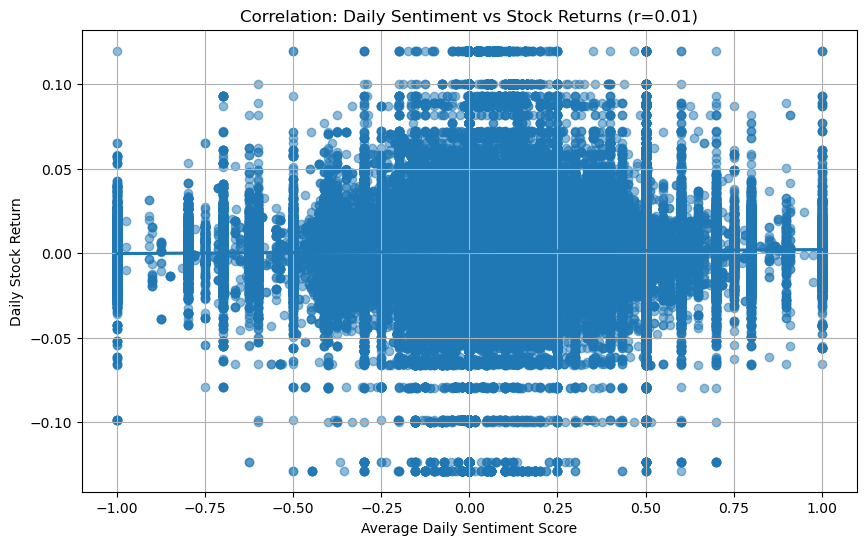

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Calculate Pearson Correlation
correlation_value = merged_df['sentiment_score'].corr(merged_df['Daily_Return'])
print(f"Pearson Correlation Coefficient: {correlation_value:.4f}")

# Visualize the Correlation (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.regplot(x='sentiment_score', y='Daily_Return', data=merged_df, scatter_kws={'alpha':0.5})
plt.title(f'Correlation: Daily Sentiment vs Stock Returns (r={correlation_value:.2f})')
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Stock Return')
plt.grid(True)
plt.show()

The correlation between news sentiment and Apple's stock price is essentially zero (0.0116), indicating that daily sentiment does not have a meaningful immediate impact on daily price levels.